# Maillage Surfacique — Exploration & Visualisation


**Sommaire**
1. Génération de primitives géométriques (sphère, cylindre, plan, tore)
2. Métriques de qualité du maillage (aspect ratio, skewness, angles)
3. Détection automatique de courbure (reconnaissance de forme)
4. Comparaison de densités de maillage
5. Export / visualisation finale

> Librairies : `trimesh` · `numpy` · `scipy` · `matplotlib`


In [ ]:
!pip install trimesh numpy scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 9.4 MB/s eta 0:00:00


## 1. Imports & configuration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import trimesh
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("Imports OK — trimesh", trimesh.__version__)


Imports OK — trimesh 4.11.5


## 2. Génération de primitives géométriques

On génère 4 primitives classiques rencontrées en maillage surfacique (pièces auto, aéronautique) :
- **Sphère** : maillage icosphère (triangles quasi-équilatéraux)
- **Cylindre** : maillage structuré radial
- **Plan** : maillage Delaunay 2D projeté
- **Tore** : surface à double courbure

Chaque primitive est représentée par ses **vertices** (coordonnées 3D) et ses **faces** (triplets d'indices).


In [ ]:
# Sphère
sphere = trimesh.creation.icosphere(subdivisions=2, radius=1.0)

# Cylindre
cylinder = trimesh.creation.cylinder(radius=0.6, height=2.0, sections=32)

# Plan bruité (Delaunay sur grille perturbée)
np.random.seed(42)
n_plane = 20
xy = np.random.uniform(-1, 1, (n_plane**2, 2))
xy += np.random.normal(0, 0.02, xy.shape)   # légère perturbation
z  = np.zeros(len(xy))
pts_plane = np.c_[xy, z]
tri_plane  = Delaunay(xy)
plane_mesh = trimesh.Trimesh(
    vertices=pts_plane,
    faces=tri_plane.simplices,
    process=False
)

# Tore
torus = trimesh.creation.torus(major_radius=1.0, minor_radius=0.35, major_segments=40, minor_segments=20)

meshes = {
    "Sphère":    sphere,
    "Cylindre":  cylinder,
    "Plan":      plane_mesh,
    "Tore":      torus,
}

for name, m in meshes.items():
    print(f"{name:10s}  {len(m.vertices):5d} vertices  {len(m.faces):5d} faces")


Sphère        162 vertices    320 faces
Cylindre       66 vertices    128 faces
Plan          400 vertices    783 faces
Tore         1024 vertices   2048 faces


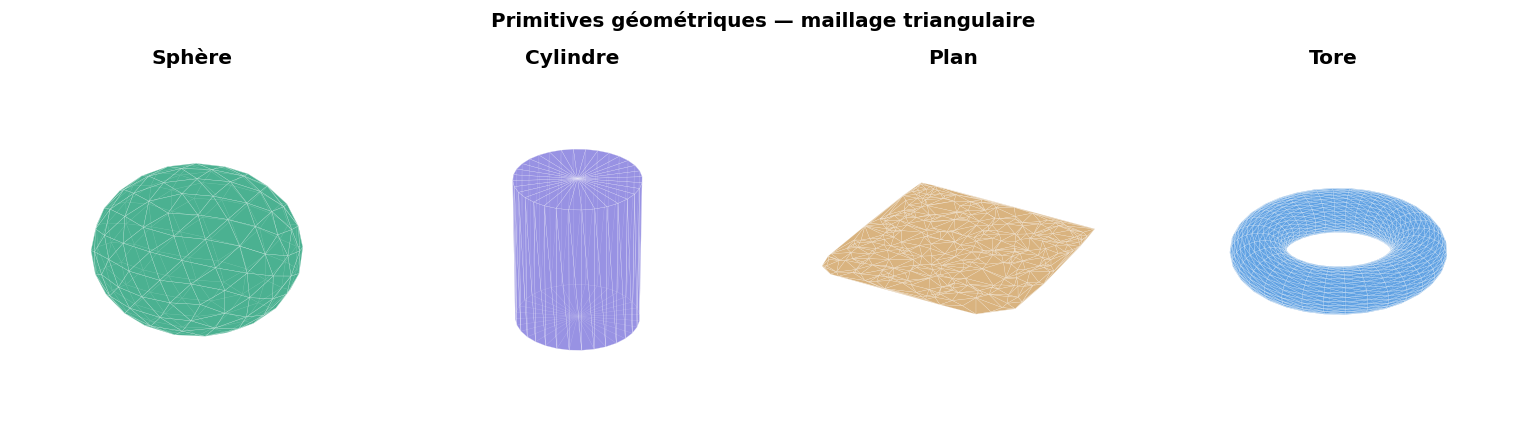

In [ ]:
# Visualisation des 4 primitives
fig = plt.figure(figsize=(14, 4))
titles = list(meshes.keys())
colors = ["#1D9E75", "#7F77DD", "#BA7517", "#378ADD"]

for i, (name, mesh) in enumerate(meshes.items()):
    ax = fig.add_subplot(1, 4, i+1, projection="3d")
    verts = mesh.vertices[mesh.faces]   # (F, 3, 3)
    poly  = Poly3DCollection(verts, alpha=0.55, linewidth=0.2)
    poly.set_facecolor(colors[i])
    poly.set_edgecolor("white")
    ax.add_collection3d(poly)
    lim = mesh.bounds
    c, r = lim.mean(axis=0), (lim[1] - lim[0]).max() / 2 + 0.1
    ax.set_xlim(c[0]-r, c[0]+r)
    ax.set_ylim(c[1]-r, c[1]+r)
    ax.set_zlim(c[2]-r, c[2]+r)
    ax.set_title(name, fontweight="bold")
    ax.set_axis_off()

plt.suptitle("Primitives géométriques — maillage triangulaire", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("primitives.png", bbox_inches="tight", dpi=130)
plt.show()


## 3. Métriques de qualité du maillage

La **qualité d'un élément** est centrale en simulation EF : un triangle trop aplati
(mauvais aspect ratio) ou trop obtus (mauvais angle) dégrade la précision du calcul.

On calcule pour chaque triangle :
- **Aspect ratio** : rapport entre la plus longue et la plus courte arête (idéal = 1)
- **Angle min/max** : les angles intérieurs (idéal : 60° pour un triangle équilatéral)
- **Skewness** : à quel point le triangle dévie de l'équilatéral (0=parfait, 1=dégénéré)


In [ ]:
def triangle_angles(verts, faces):
    """Retourne les 3 angles intérieurs (en degrés) pour chaque face."""
    v0, v1, v2 = verts[faces[:,0]], verts[faces[:,1]], verts[faces[:,2]]
    def angle(a, b, c):
        u = b - a; v_ = c - a
        cos_a = np.einsum("ij,ij->i", u, v_) / (
            np.linalg.norm(u, axis=1) * np.linalg.norm(v_, axis=1) + 1e-12)
        return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))
    a0 = angle(v0, v1, v2)
    a1 = angle(v1, v0, v2)
    a2 = 180 - a0 - a1
    return np.stack([a0, a1, a2], axis=1)   # (F, 3)

def aspect_ratio(verts, faces):
    """Rapport longueur max / longueur min des arêtes."""
    v0, v1, v2 = verts[faces[:,0]], verts[faces[:,1]], verts[faces[:,2]]
    e0 = np.linalg.norm(v1-v0, axis=1)
    e1 = np.linalg.norm(v2-v1, axis=1)
    e2 = np.linalg.norm(v0-v2, axis=1)
    edges = np.stack([e0, e1, e2], axis=1)
    return edges.max(axis=1) / (edges.min(axis=1) + 1e-12)

def skewness(angles_deg):
    """Skewness basée sur la déviation par rapport à 60°."""
    return np.max(np.abs(angles_deg - 60) / 60, axis=1)

# Calcul sur les 4 maillages
metrics = {}
for name, mesh in meshes.items():
    ang = triangle_angles(mesh.vertices, mesh.faces)
    ar  = aspect_ratio(mesh.vertices, mesh.faces)
    sk  = skewness(ang)
    metrics[name] = {
        "aspect_ratio": ar,
        "angle_min":    ang.min(axis=1),
        "angle_max":    ang.max(axis=1),
        "skewness":     sk,
    }
    print(f"{name:10s}  AR moy={ar.mean():.2f}  "
          f"angle_min moy={ang.min(axis=1).mean():.1f}°  "
          f"skewness moy={sk.mean():.3f}")


Sphère      AR moy=1.11  angle_min moy=55.9°  skewness moy=0.118
Cylindre    AR moy=11.07  angle_min moy=7.3°  skewness moy=0.878
Plan        AR moy=2.63  angle_min moy=28.9°  skewness moy=0.678
Tore        AR moy=3.04  angle_min moy=20.3°  skewness moy=0.662


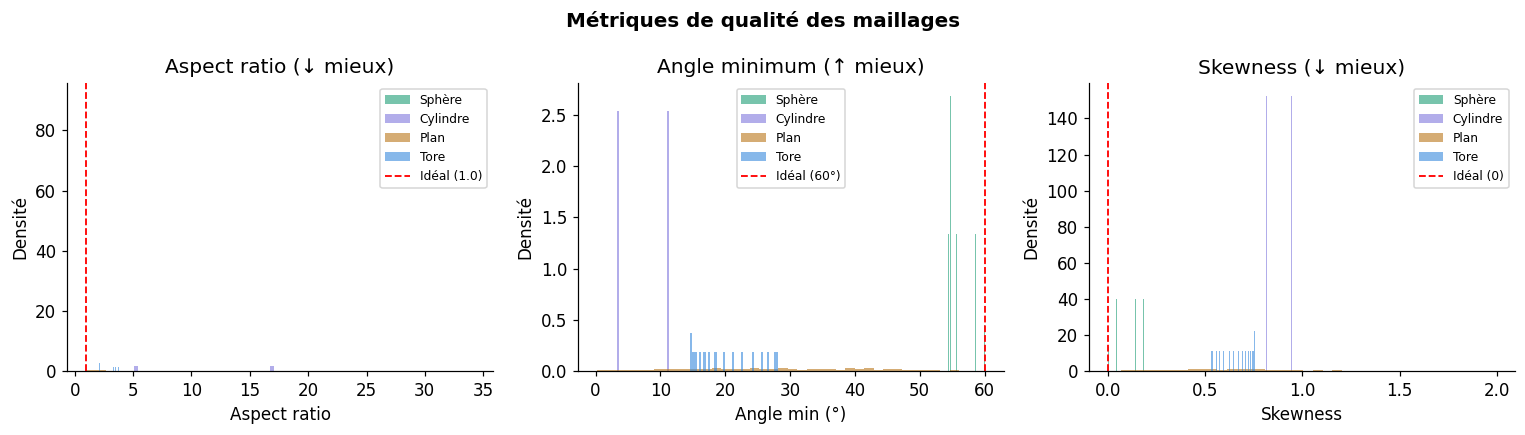

In [ ]:
# Histogrammes comparatifs
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bins = 40

for name, color in zip(meshes.keys(), colors):
    m = metrics[name]
    axes[0].hist(m["aspect_ratio"], bins=bins, alpha=0.6, label=name,
                 color=color, density=True)
    axes[1].hist(m["angle_min"],    bins=bins, alpha=0.6, label=name,
                 color=color, density=True)
    axes[2].hist(m["skewness"],     bins=bins, alpha=0.6, label=name,
                 color=color, density=True)

axes[0].axvline(1.0, color="red", lw=1.2, ls="--", label="Idéal (1.0)")
axes[1].axvline(60,  color="red", lw=1.2, ls="--", label="Idéal (60°)")
axes[2].axvline(0.0, color="red", lw=1.2, ls="--", label="Idéal (0)")

axes[0].set_xlabel("Aspect ratio"); axes[0].set_title("Aspect ratio (↓ mieux)")
axes[1].set_xlabel("Angle min (°)"); axes[1].set_title("Angle minimum (↑ mieux)")
axes[2].set_xlabel("Skewness");      axes[2].set_title("Skewness (↓ mieux)")

for ax in axes:
    ax.legend(fontsize=8)
    ax.set_ylabel("Densité")

plt.suptitle("Métriques de qualité des maillages", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("quality_metrics.png", bbox_inches="tight", dpi=130)
plt.show()


## 4. Détection de courbure — reconnaissance de forme

La **courbure** est la signature géométrique qui distingue les primitives.
On calcule la **courbure gaussienne discrète** via le défaut angulaire.

- **Sphère** : courbure gaussienne constante $> 0$
- **Cylindre** : courbure nulle sur la paroi (surface réglée)
- **Plan** : courbure nulle partout
- **Tore** : courbure positive (extérieur) et négative (intérieur)


In [ ]:
def gaussian_curvature(mesh):
    """
    Courbure gaussienne discrète par défaut angulaire.
    Retourne un array (n_vertices,).
    """
    verts  = mesh.vertices
    faces  = mesh.faces
    n_v    = len(verts)
    angle_sum = np.zeros(n_v)
    area_sum  = np.zeros(n_v)

    for f in faces:
        v0, v1, v2 = verts[f[0]], verts[f[1]], verts[f[2]]
        # Aires et angles
        face_verts = [v0, v1, v2]
        face_idx   = f
        edge_vecs  = [
            face_verts[1] - face_verts[0],
            face_verts[2] - face_verts[1],
            face_verts[0] - face_verts[2],
        ]
        cross = np.cross(-edge_vecs[2], edge_vecs[0])
        area  = np.linalg.norm(cross) / 2.0

        for j in range(3):
            a = face_verts[(j+1)%3] - face_verts[j]
            b = face_verts[(j+2)%3] - face_verts[j]
            cos_a = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)
            theta = np.arccos(np.clip(cos_a, -1, 1))
            angle_sum[face_idx[j]] += theta
            area_sum[face_idx[j]]  += area / 3.0

    K = (2 * np.pi - angle_sum) / (area_sum + 1e-12)
    return K

curv = {}
for name, mesh in meshes.items():
    K = gaussian_curvature(mesh)
    curv[name] = K
    print(f"{name:10s}  K_moy={K.mean():+.3f}  K_std={K.std():.3f}  "
          f"[{K.min():+.2f}, {K.max():+.2f}]")


Sphère      K_moy=+1.021  K_std=0.038  [+1.01, +1.15]
Cylindre    K_moy=+1.350  K_std=0.239  [-0.00, +1.39]
Plan        K_moy=+21.947  K_std=156.999  [-0.00, +1891.75]
Tore        K_moy=-0.548  K_std=2.266  [-4.38, +2.12]


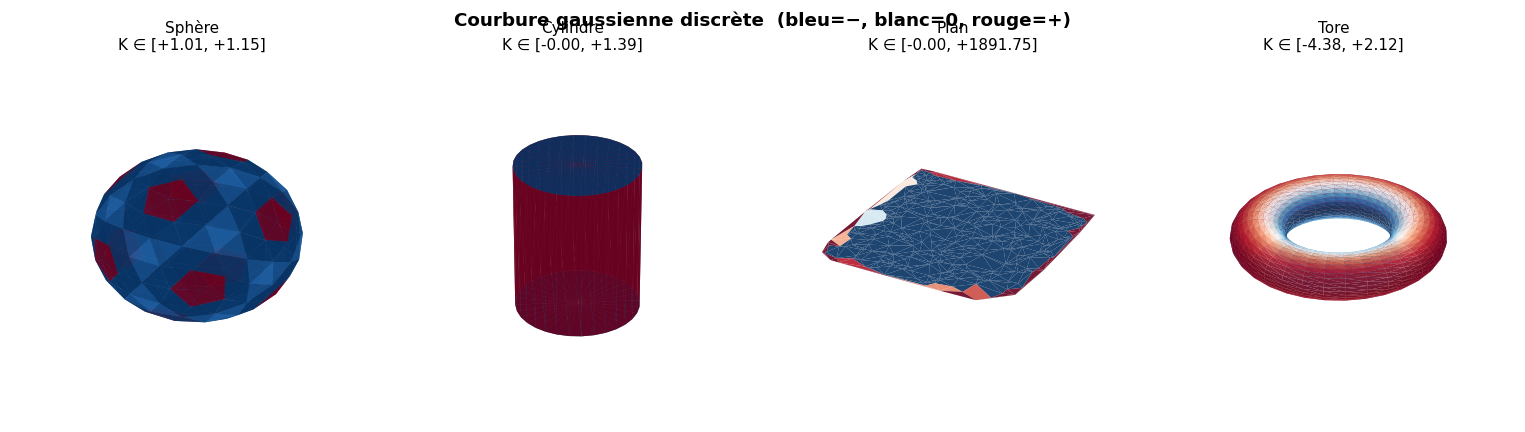

In [ ]:
# Visualisation de la courbure sur la surface
fig = plt.figure(figsize=(14, 4))

for i, (name, mesh) in enumerate(meshes.items()):
    K   = curv[name]
    ax  = fig.add_subplot(1, 4, i+1, projection="3d")
    v   = mesh.vertices
    f   = mesh.faces

    # Courbure par face = moyenne des sommets
    K_face = K[f].mean(axis=1)
    # Clip pour la visualisation (le tore a des valeurs extrêmes)
    vmin, vmax = np.percentile(K_face, 5), np.percentile(K_face, 95)
    K_norm = np.clip((K_face - vmin) / (vmax - vmin + 1e-9), 0, 1)

    cmap   = plt.cm.RdBu_r
    fcolors = cmap(K_norm)

    poly = Poly3DCollection(v[f], linewidth=0, alpha=0.9)
    poly.set_facecolor(fcolors)
    ax.add_collection3d(poly)

    lim = mesh.bounds
    c   = lim.mean(axis=0)
    r   = (lim[1] - lim[0]).max() / 2 + 0.1
    ax.set_xlim(c[0]-r, c[0]+r)
    ax.set_ylim(c[1]-r, c[1]+r)
    ax.set_zlim(c[2]-r, c[2]+r)
    ax.set_title(f"{name}\nK ∈ [{K.min():+.2f}, {K.max():+.2f}]", fontsize=10)
    ax.set_axis_off()

plt.suptitle("Courbure gaussienne discrète  (bleu=−, blanc=0, rouge=+)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("curvature.png", bbox_inches="tight", dpi=130)
plt.show()


## 5. Classification de forme par signature de courbure

Sans apprentissage machine, on peut déjà **reconnaître automatiquement** les primitives
en calculant quelques statistiques simples sur la distribution de courbure :

| Primitive | K_mean | K_std | Fraction K≈0 |
|-----------|--------|-------|-------------|
| Sphère    | > 0    | faible | faible |
| Cylindre  | ≈ 0    | faible | élevée |
| Plan      | ≈ 0    | très faible | très élevée |
| Tore      | ≈ 0    | élevé | intermédiaire |



In [ ]:
def curvature_features(K, eps=0.05):
    """Extrait un vecteur de features à partir de la distribution de courbure."""
    return {
        "K_mean":        K.mean(),
        "K_std":         K.std(),
        "K_abs_mean":    np.abs(K).mean(),
        "frac_flat":     (np.abs(K) < eps).mean(),    # fraction de surface plate
        "frac_positive": (K > eps).mean(),             # courbure convexe
        "frac_negative": (K < -eps).mean(),            # courbure concave (selle)
        "skew":          float(np.mean(((K - K.mean())/K.std()+1e-9)**3)) if K.std() > 1e-6 else 0.0,
    }

print(f"{'Forme':10s}  {'K_mean':>8}  {'K_std':>7}  {'frac_flat':>10}  {'frac_pos':>9}  {'frac_neg':>9}")
print("─" * 65)
feat_all = {}
for name, K in curv.items():
    f = curvature_features(K)
    feat_all[name] = f
    print(f"{name:10s}  {f['K_mean']:+8.4f}  {f['K_std']:7.4f}  "
          f"{f['frac_flat']:10.2%}  {f['frac_positive']:9.2%}  {f['frac_negative']:9.2%}")


Forme         K_mean    K_std   frac_flat   frac_pos   frac_neg
─────────────────────────────────────────────────────────────────
Sphère       +1.0213   0.0376       0.00%    100.00%      0.00%
Cylindre     +1.3501   0.2387       3.03%     96.97%      0.00%
Plan        +21.9470  156.9988      96.25%      3.75%      0.00%
Tore         -0.5482   2.2659       6.25%     46.88%     46.88%


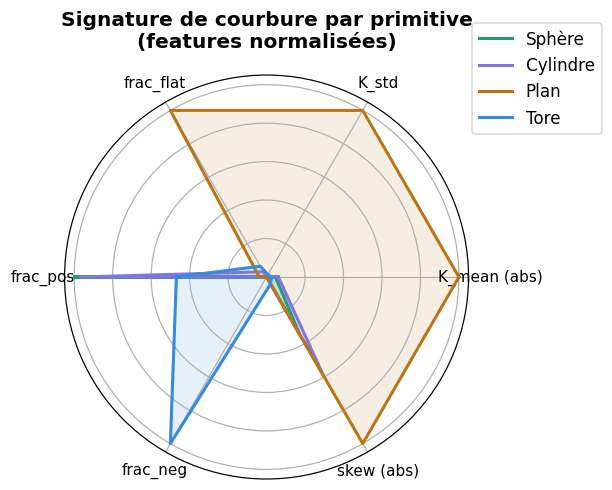

In [ ]:
# Radar chart des features
import matplotlib.patches as mpatches

feature_labels = ["K_mean (abs)", "K_std", "frac_flat", "frac_pos", "frac_neg", "skew (abs)"]
N = len(feature_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Normalisation 0-1 pour le radar
raw = np.array([[
    abs(feat_all[n]["K_mean"]),
    feat_all[n]["K_std"],
    feat_all[n]["frac_flat"],
    feat_all[n]["frac_positive"],
    feat_all[n]["frac_negative"],
    abs(feat_all[n]["skew"]),
] for n in meshes.keys()])
mx = raw.max(axis=0) + 1e-9
raw_norm = raw / mx

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})

for i, (name, color) in enumerate(zip(meshes.keys(), colors)):
    vals = raw_norm[i].tolist() + [raw_norm[i][0]]
    ax.plot(angles, vals, color=color, lw=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_labels, size=10)
ax.set_yticklabels([])
ax.set_title("Signature de courbure par primitive\n(features normalisées)",
             fontweight="bold", pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig("radar_features.png", bbox_inches="tight", dpi=130)
plt.show()


## 6. Effet de la densité de maillage

Un paramètre clé en pratique : la **résolution** du maillage.
Un maillage trop grossier rate les détails géométriques (courbure sous-échantillonnée).
Un maillage trop fin explose les temps de calcul EF.

On compare 3 résolutions sur la sphère et on regarde l'erreur sur la courbure théorique ($K = 1/r^2 = 1$ pour $r=1$).


subdiv=0  |     20 faces  |  K_moy=1.3125  |  err_moy=0.3125
subdiv=1  |     80 faces  |  K_moy=1.0835  |  err_moy=0.0835
subdiv=2  |    320 faces  |  K_moy=1.0213  |  err_moy=0.0213
subdiv=3  |   1280 faces  |  K_moy=1.0053  |  err_moy=0.0053


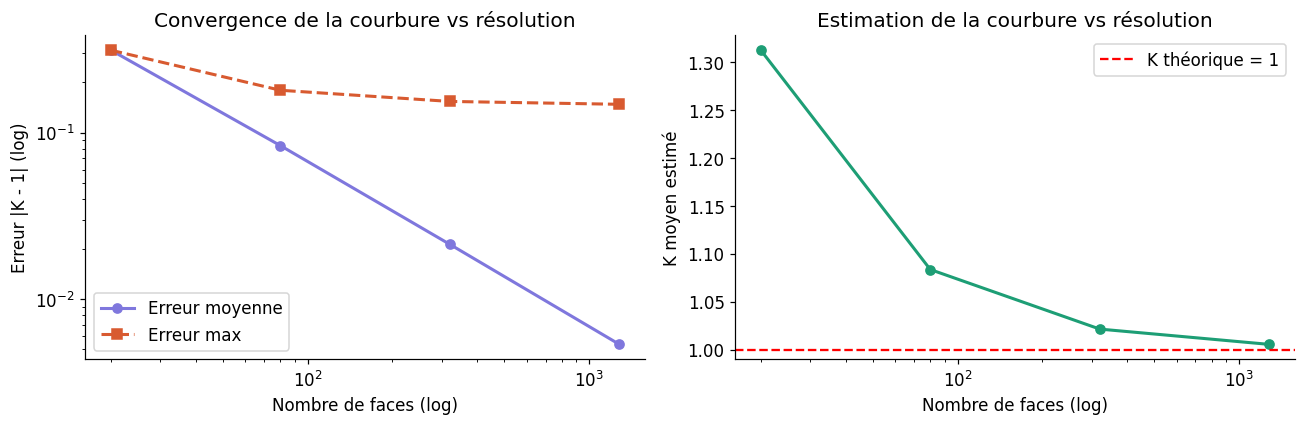

In [ ]:
subdiv_levels = [0, 1, 2, 3]
sphere_resolutions = {
    f"subdiv={s}": trimesh.creation.icosphere(subdivisions=s, radius=1.0)
    for s in subdiv_levels
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
K_theoretical = 1.0   # sphère unité

rows = []
for label, mesh in sphere_resolutions.items():
    K     = gaussian_curvature(mesh)
    err   = np.abs(K - K_theoretical)
    rows.append({
        "label":    label,
        "n_faces":  len(mesh.faces),
        "K_mean":   K.mean(),
        "K_err_mean": err.mean(),
        "K_err_max":  err.max(),
    })
    print(f"{label}  |  {len(mesh.faces):5d} faces  "
          f"|  K_moy={K.mean():.4f}  |  err_moy={err.mean():.4f}")

# Graphe erreur vs résolution
n_faces = [r["n_faces"] for r in rows]
err_moy = [r["K_err_mean"] for r in rows]
err_max = [r["K_err_max"]  for r in rows]

axes[0].loglog(n_faces, err_moy, "o-", color="#7F77DD", lw=2, label="Erreur moyenne")
axes[0].loglog(n_faces, err_max, "s--", color="#D85A30", lw=2, label="Erreur max")
axes[0].set_xlabel("Nombre de faces (log)")
axes[0].set_ylabel("Erreur |K - 1| (log)")
axes[0].set_title("Convergence de la courbure vs résolution")
axes[0].legend()

# K_mean vs résolution
axes[1].semilogx(n_faces, [r["K_mean"] for r in rows], "o-", color="#1D9E75", lw=2)
axes[1].axhline(1.0, color="red", ls="--", label="K théorique = 1")
axes[1].set_xlabel("Nombre de faces (log)")
axes[1].set_ylabel("K moyen estimé")
axes[1].set_title("Estimation de la courbure vs résolution")
axes[1].legend()

plt.tight_layout()
plt.savefig("resolution_convergence.png", bbox_inches="tight", dpi=130)
plt.show()


## 7. Récapitulatif & pistes suivantes

| Étape | Contenu |
|-------|---------|
| Génération | 4 primitives triangulées avec trimesh |
| Métriques | Aspect ratio, angle min, skewness |
| Courbure | Courbure gaussienne discrète par défaut angulaire |
| Signature | Vecteur de features par forme -> base pour un classifieur |
| Convergence | Erreur de courbure vs résolution du maillage |

Ces **features de courbure** sont exactement le type de signal qu'un réseau de neurones
(PointNet, GNN) peut apprendre à combiner automatiquement pour :
- identifier la primitive locale autour de chaque vertex
- déduire la stratégie de maillage optimale à recopier

La prochaine étape serait d'entraîner un classifieur sur ces features, ou directement
sur le nuage de points brut (PointNet).

### Pistes d'extension
- **Maillage adaptatif** : affiner là où la courbure est élevée
- **Segmentation** : partitionner un maillage complexe en régions de primitives
- **GNN** : modéliser le maillage comme graphe (vertices → noeuds, arêtes → connexions)
